# Plotting for Project 2

In [30]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from colormaps import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
np.random.seed(27)

# x0_map = {
#     "Simple1": np.array([[-2,2], [1, -2], [1.5, 1]]),
#     "Simple2": np.array([[2,2], [-1, -1], [3, 3]]),
#     "Simple3": np.array([[1,1,1], [-1, -3, -1], [2, 2, 1]]),
# }
# 10 random initializations in the range [-3, 3]
n_samples = 4
x0_map = {
    "Simple1": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 2),
    "Simple2": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 2),
    "Simple3": np.round(np.random.uniform(-3, 3, (n_samples, 3)), 2),
}

x_best_map = {
    "Simple1": np.array([2/3, 1/np.sqrt(3)]),
    "Simple2": np.array([1,1]),
    "Simple3": np.array([-1/np.sqrt(6), np.sqrt(2/3), -1/np.sqrt(6)]),
}

## Quadratic penalty L-BFGS

In [32]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}
g_pen_hists = {}
g_hists = {}
pen_g_hists = {}
c_max_vio_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history, g_pen_history, g_history, pen_g_history = penalty_l_bfgs(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['quadratic_penalty_l_bfgs'], penalty_mode='quadratic')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-0.45  1.89], x_best: [0. 0.], f(x_best): 0.3849001794597505, c(x_best): [-1. -0.]
Problem: Simple1, x0: [1.41 2.21], x_best: [0.87220944 0.35472432], f(x_best): 0.07550628008092386, c(x_best): [-0.00196122 -1.22693376]
Problem: Simple1, x0: [-0.7   2.88], x_best: [0. 0.], f(x_best): 0.3849001794597505, c(x_best): [-1. -0.]
Problem: Simple1, x0: [ 2.36 -1.74], x_best: [0.60171486 0.63147948], f(x_best): 0.004929595228720829, c(x_best): [ 4.81188973e-04 -1.23319434e+00]
Problem: Simple2, x0: [1.45 0.98], x_best: [-1.46871998  2.25070929], f(x_best): 6.970129871495792, c(x_best): [-16.29651659  -1.21801069]
Problem: Simple2, x0: [2.32 2.15], x_best: [-1.94407083  3.90812608], f(x_best): 10.32430012051058, c(x_best): [-28.42601617  -0.03594475]
Problem: Simple2, x0: [1.5  2.22], x_best: [-0.67782737  0.47594479], f(x_best): 2.8423126930585054, c(x_best): [-4.19920449 -2.20188258]
Problem: Simple2, x0: [-1.88 -1.05], x_best: [-1.43931088  1.97584675], f(x_best): 6.86

### Contour plot with feasible region for Simple1

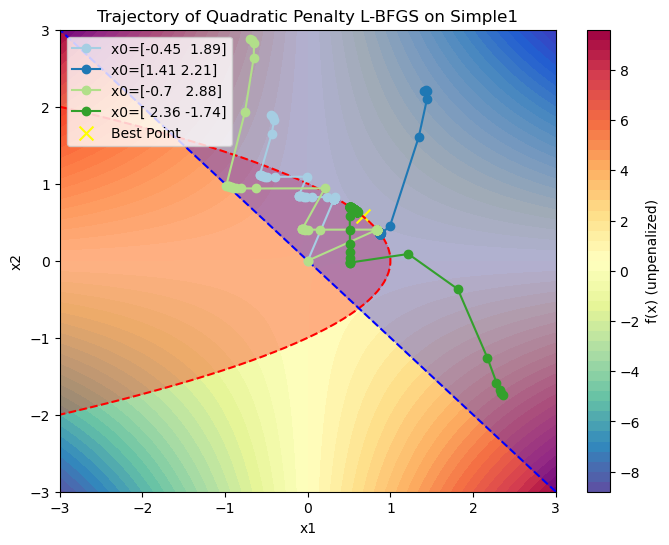

In [33]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty L-BFGS on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

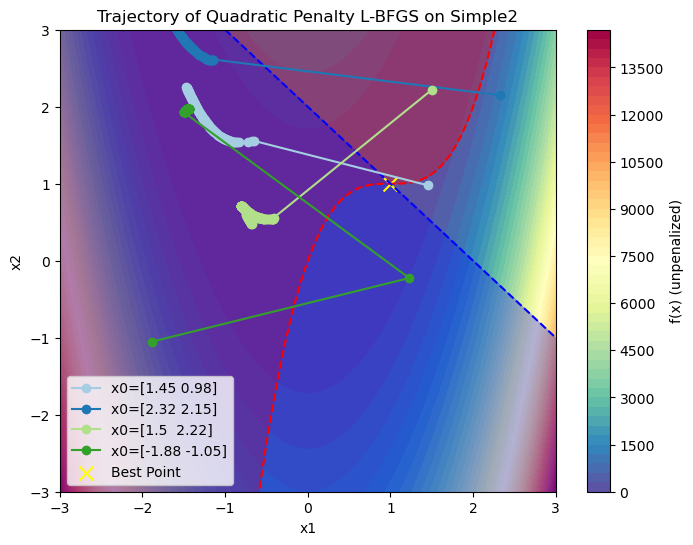

In [34]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty L-BFGS on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

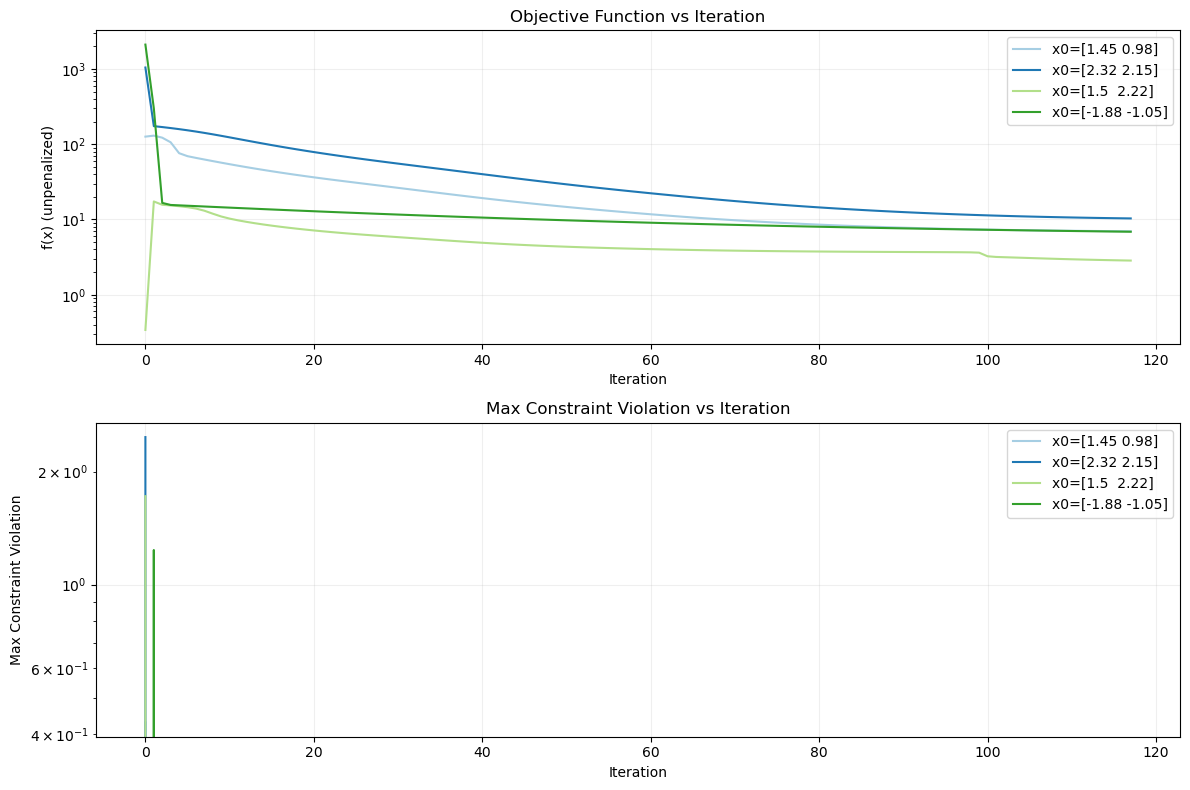

In [35]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    

## Quadratic penalty gradient descent

In [36]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history = penalty_gradient_descent(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['quadratic_penalty_gradient_descent'], penalty_mode='quadratic')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-0.45  1.89], x_best: [0.64143148 0.59955338], f(x_best): 0.0003277691768192592, c(x_best): [ 8.95732261e-04 -1.24098486e+00]
Problem: Simple1, x0: [1.41 2.21], x_best: [0.63037494 0.60828803], f(x_best): 0.0014506510979997445, c(x_best): [ 3.89264303e-04 -1.23866297e+00]
Problem: Simple1, x0: [-0.7   2.88], x_best: [0.62597117 0.61195681], f(x_best): 0.0018328590676683354, c(x_best): [ 4.62307012e-04 -1.23792798e+00]
Problem: Simple1, x0: [ 2.36 -1.74], x_best: [0. 0.], f(x_best): 0.3849001794597505, c(x_best): [-1. -0.]
Problem: Simple2, x0: [1.45 0.98], x_best: [1.2895316  1.67337296], f(x_best): 0.09481412624500542, c(x_best): [-0.64910195  0.96290457]
Problem: Simple2, x0: [2.32 2.15], x_best: [0.99999557 1.00000008], f(x_best): 8.014290098092015e-09, c(x_best): [-8.28042761e-08 -4.34644983e-06]
Problem: Simple2, x0: [1.5  2.22], x_best: [0.99999963 0.99999998], f(x_best): 5.0166344270352735e-11, c(x_best): [ 2.43293993e-08 -3.90162479e-07]
Problem: Simple2,

### Contour plot with feasible region for Simple1

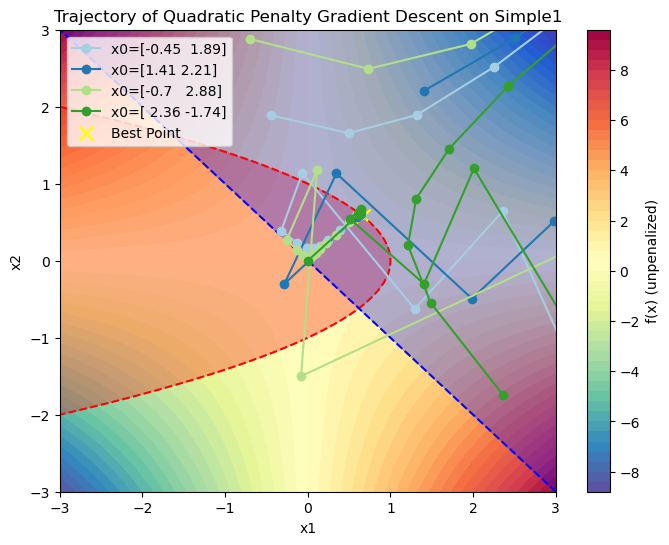

In [37]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty Gradient Descent on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

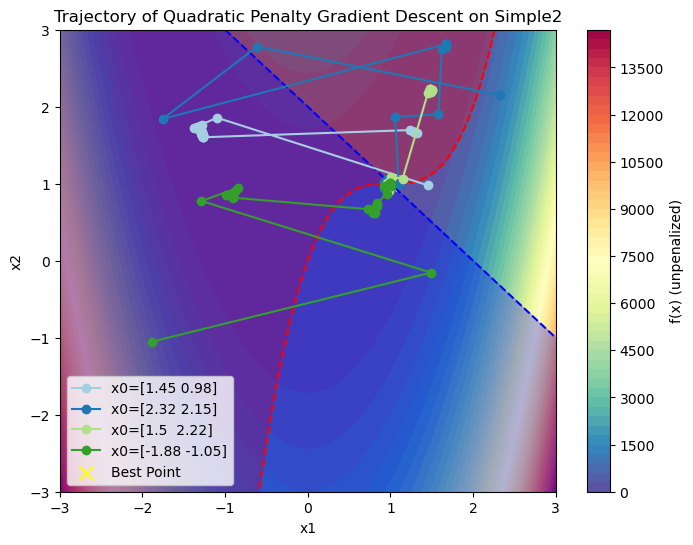

In [38]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty Gradient Descent on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

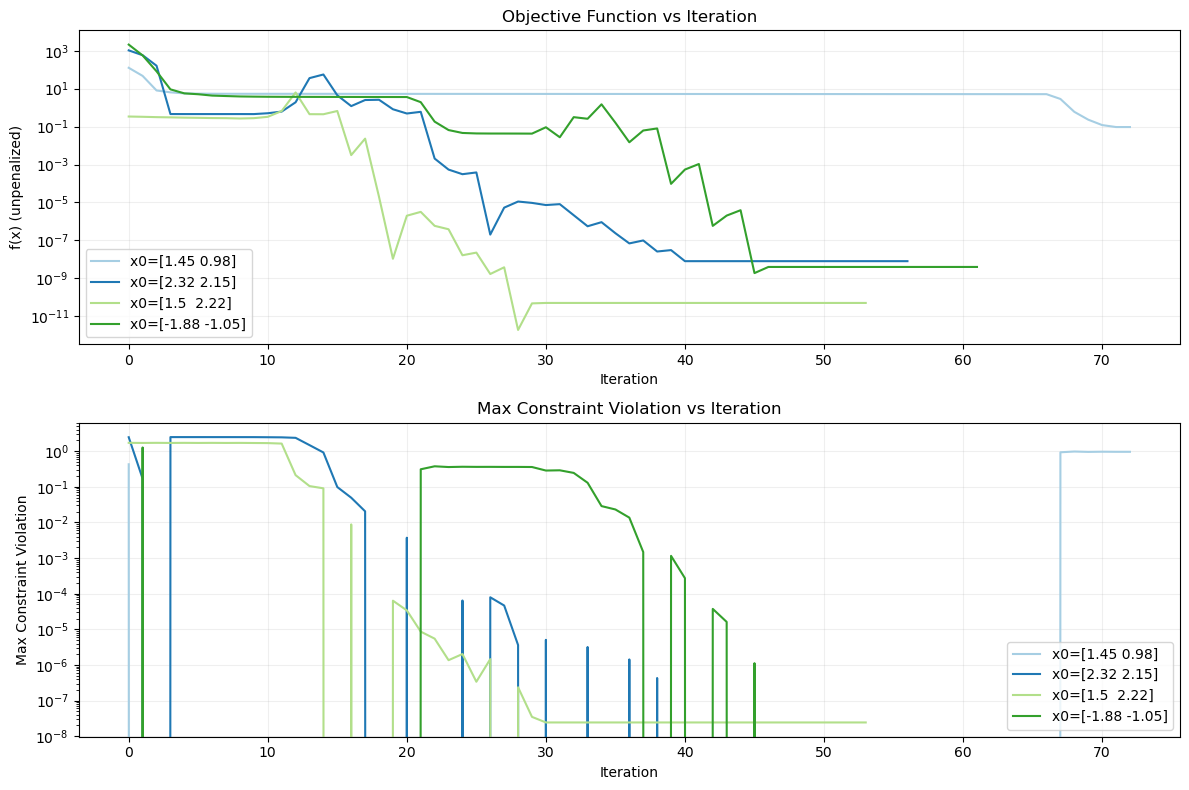

In [39]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    

## Absolute penalty L-BFGS

In [40]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}
g_pen_hists = {}
g_hists = {}
pen_g_hists = {}
c_max_vio_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history, g_pen_history, g_history, pen_g_history = penalty_l_bfgs(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['absolute_penalty_l_bfgs'], penalty_mode='absolute')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-0.45  1.89], x_best: [-0.07126386  0.27150919], f(x_best): 0.40424897265349696, c(x_best): [-0.99754662 -0.20024533]
Problem: Simple1, x0: [1.41 2.21], x_best: [0.93233264 0.0248663 ], f(x_best): 0.3617165154700035, c(x_best): [-0.06704903 -0.95719894]
Problem: Simple1, x0: [-0.7   2.88], x_best: [0.17689541 0.75892226], f(x_best): 0.25065031206472177, c(x_best): [-0.24714159 -0.93581767]
Problem: Simple1, x0: [ 2.36 -1.74], x_best: [0.12454105 0.70495384], f(x_best): 0.2971044900204486, c(x_best): [-0.37849904 -0.82949489]
Problem: Simple2, x0: [1.45 0.98], x_best: [-1.54411303  2.47842333], f(x_best): 7.358712740152234, c(x_best): [-17.94522319  -1.0656897 ]
Problem: Simple2, x0: [2.32 2.15], x_best: [-0.96658077  0.88060861], f(x_best): 4.155484382932755, c(x_best): [-7.4862416  -2.08597216]
Problem: Simple2, x0: [1.5  2.22], x_best: [-0.87138215  0.4376078 ], f(x_best): 13.851099706151976, c(x_best): [-5.99132126 -2.43377436]
Problem: Simple2, x0: [-1.88 -1.

### Contour plot with feasible region for Simple1

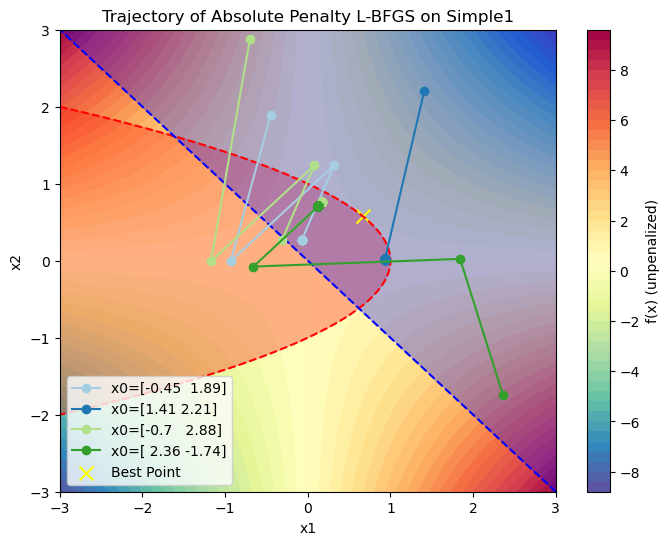

In [41]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty L-BFGS on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

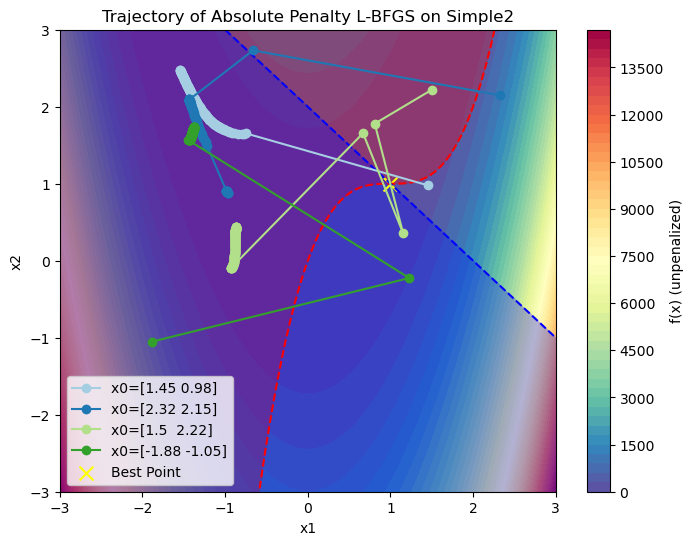

In [42]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty L-BFGS on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

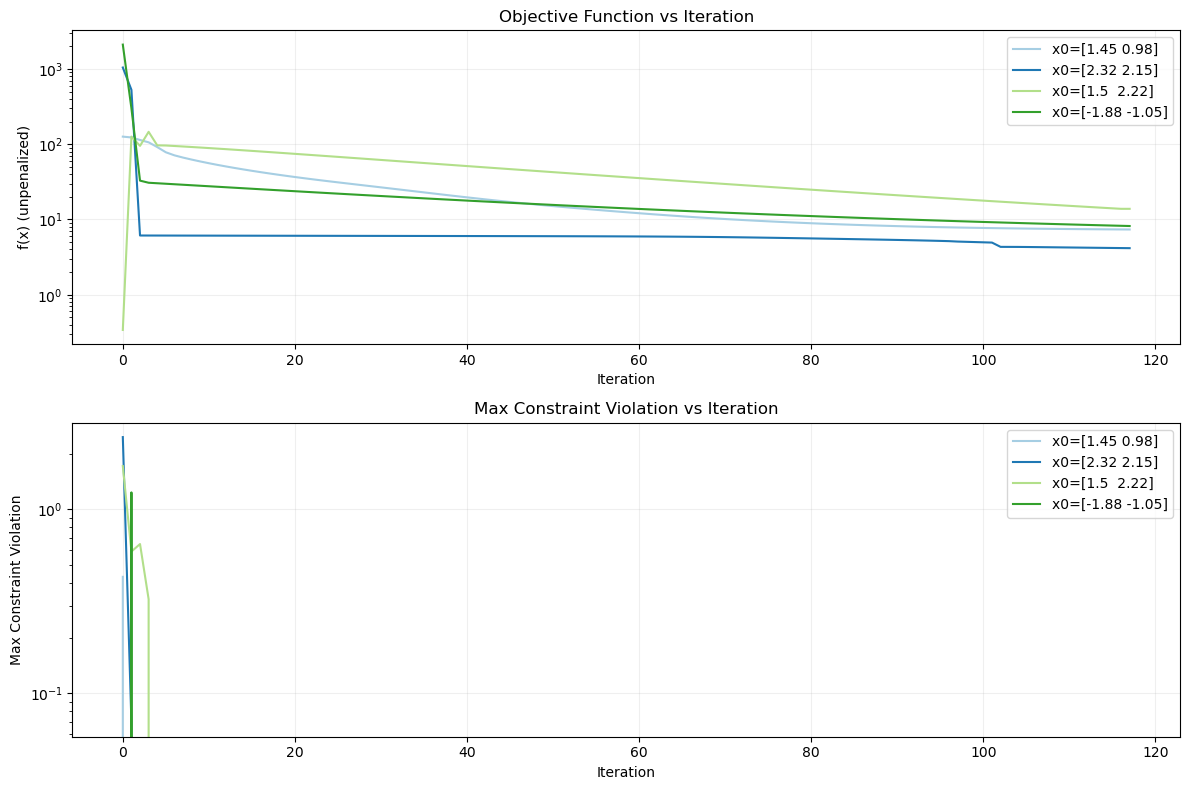

In [43]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    

## Absolute penalty gradient descent

In [44]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        if p_name.__name__ == "Simple1":
            key = "simple1"
        if p_name.__name__ == "Simple2":
            key = "simple2"
        if p_name.__name__ == "Simple3":
            key = "simple3"
        x_history, f_pen_history, f_history, pen_f_history = penalty_gradient_descent(p.f, p.g, p.c, x0, 2000, p.count, strategy_config_map[key]['absolute_penalty_gradient_descent'], penalty_mode='absolute')

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-0.45  1.89], x_best: [0.15999788 0.9165162 ], f(x_best): 0.23825953000607528, c(x_best): [-1.80146742e-07 -1.07651408e+00]
Problem: Simple1, x0: [1.41 2.21], x_best: [0.91960332 0.28354211], f(x_best): 0.12415391037091111, c(x_best): [-5.46082042e-07 -1.20314544e+00]
Problem: Simple1, x0: [-0.7   2.88], x_best: [0.28453883 0.84584892], f(x_best): 0.14422332275660732, c(x_best): [-7.87101788e-07 -1.13038774e+00]
Problem: Simple1, x0: [ 2.36 -1.74], x_best: [0.87523211 0.35322488], f(x_best): 0.07574642335979631, c(x_best): [-7.62911982e-08 -1.22845699e+00]
Problem: Simple2, x0: [1.45 0.98], x_best: [0.99957913 1.0000002 ], f(x_best): 7.103241643241845e-05, c(x_best): [-1.9937349e-07 -4.2066753e-04]
Problem: Simple2, x0: [2.32 2.15], x_best: [0.00253296 0.00758038], f(x_best): 1.0006769943949596, c(x_best): [-7.39028754e-07 -1.98988666e+00]
Problem: Simple2, x0: [1.5  2.22], x_best: [0.99797425 1.00000066], f(x_best): 0.0016427815967314427, c(x_best): [-6.69659173

### Contour plot with feasible region for Simple1

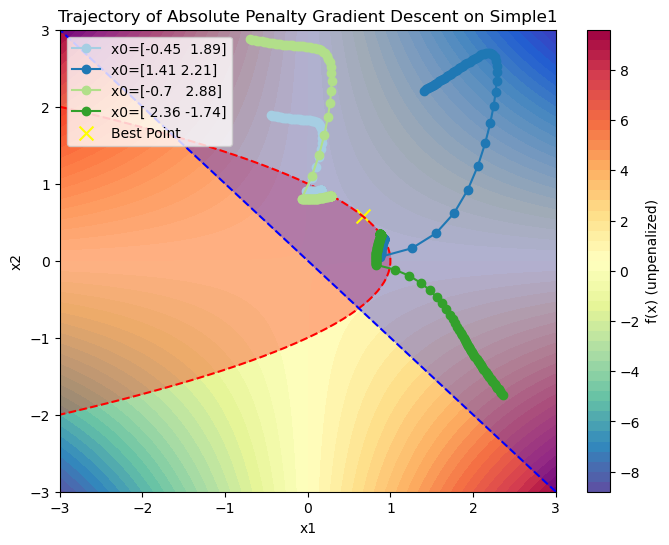

In [45]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty Gradient Descent on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

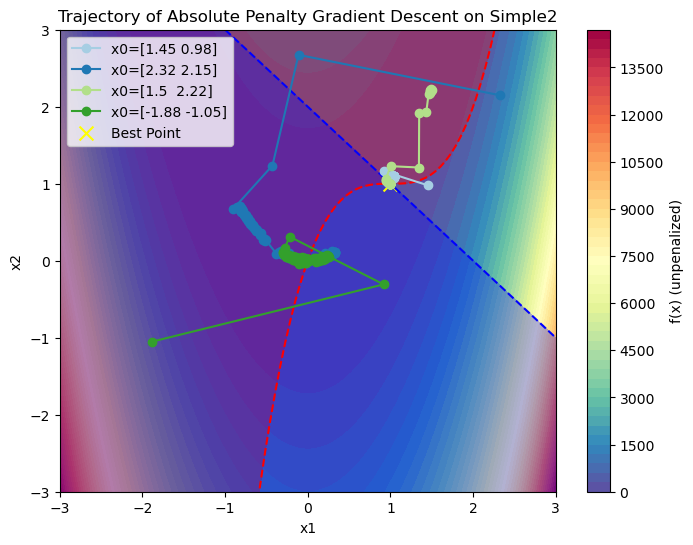

In [46]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Absolute Penalty Gradient Descent on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

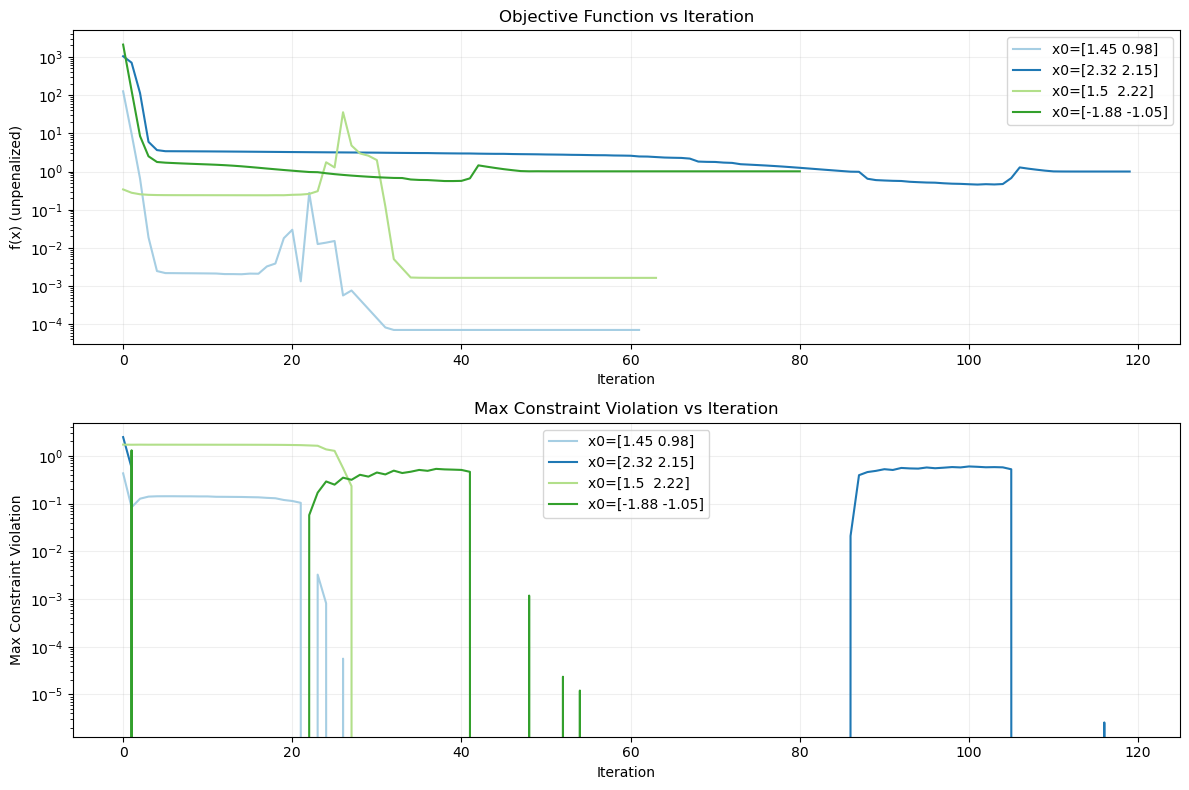

In [47]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    